# Norwegian reservoir filling data

This notebook is the analysis and documentation workspace for the IND320 reservoir project. It loads the local `reservoirs.csv` file, gives its fields readable English names, and uses Seaborn to examine how numeric measurements change over time. The companion Streamlit app uses numeric fill-level values from the same CSV to show weekly area series.

In [1]:
# Import packages for the time-series plots below.

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# Load the source data and replace abbreviated Norwegian headers.
df = pd.read_csv("reservoirs.csv")
df.columns = [
    "Observation Date",
    "Area Type",
    "Area Code",
    "Iso Year",
    "Iso Week",
    "Fill Level",
    "Capacity TWh",
    "Stored Energy TWh",
    "Next Publication Date",
    "Previous Week Fill Level",
    "Weekly Fill Level Change",
]

# The source uses 0001-01-01 as a placeholder for an unavailable publication date.
df["Observation Date"] = pd.to_datetime(
    df["Observation Date"], format="%Y-%m-%d", errors="coerce"
)
df["Next Publication Date"] = pd.to_datetime(
    df["Next Publication Date"], format="ISO8601", errors="coerce"
)

df.head()

,Observation Date,Area Type,Area Code,Iso Year,Iso Week,Fill Level,Capacity TWh,Stored Energy TWh,Next Publication Date,Previous Week Fill Level,Weekly Fill Level Change
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,NaT,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25 13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,NaT,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,NaT,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,NaT,0.311122,-0.010301


## Weekly fill levels by area

Each line follows one of the nine area series through time. The national series (`NO 0`) is an aggregate, while `EL` and `VASS` are the area codes supplied in the CSV. Fill level is shown as a percentage of capacity.

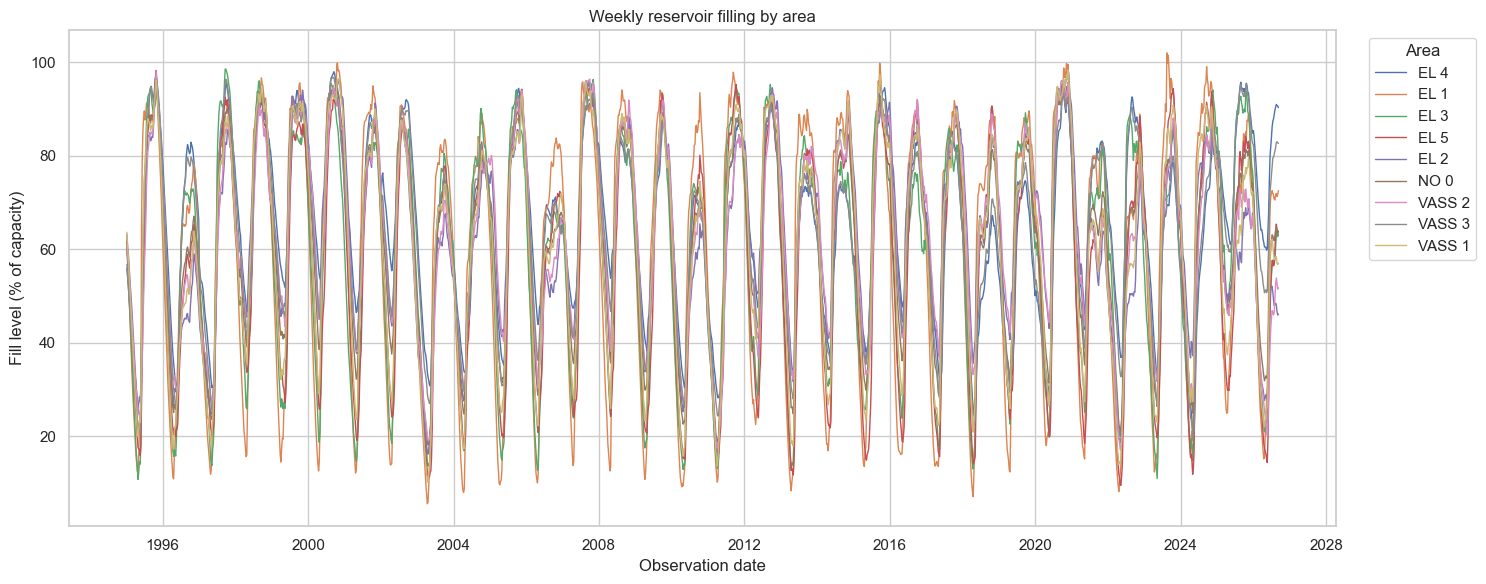

In [3]:
# Use the date as the x-axis and keep area codes as labels, not measurements.
fill_data = df[["Observation Date", "Area Type", "Area Code", "Fill Level"]].copy()
fill_data["Area"] = fill_data["Area Type"] + " " + fill_data["Area Code"].astype(str)
fill_data["Fill Level (%)"] = fill_data["Fill Level"] * 100

fig, ax = plt.subplots(figsize=(15, 6))
sns.lineplot(
    data=fill_data, x="Observation Date", y="Fill Level (%)", hue="Area",
    estimator=None, errorbar=None, linewidth=1, ax=ax,
)
ax.set_title("Weekly reservoir filling by area")
ax.set_xlabel("Observation date")
ax.set_ylabel("Fill level (% of capacity)")
ax.legend(title="Area", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

## Standardised national measurements over time

The national series (`NO 0`) keeps the comparison at one consistent geographic level. Fill level, stored energy, previous-week fill level, and weekly change have different units or ranges, so each is standardised to a z-score before sharing one plot. A value of zero is that measurement's own mean; one is one standard deviation above it. ISO year and week describe the date axis, and national capacity is constant, so they are not standardised as measurements. Fill level and stored energy nearly overlap because national capacity is fixed.

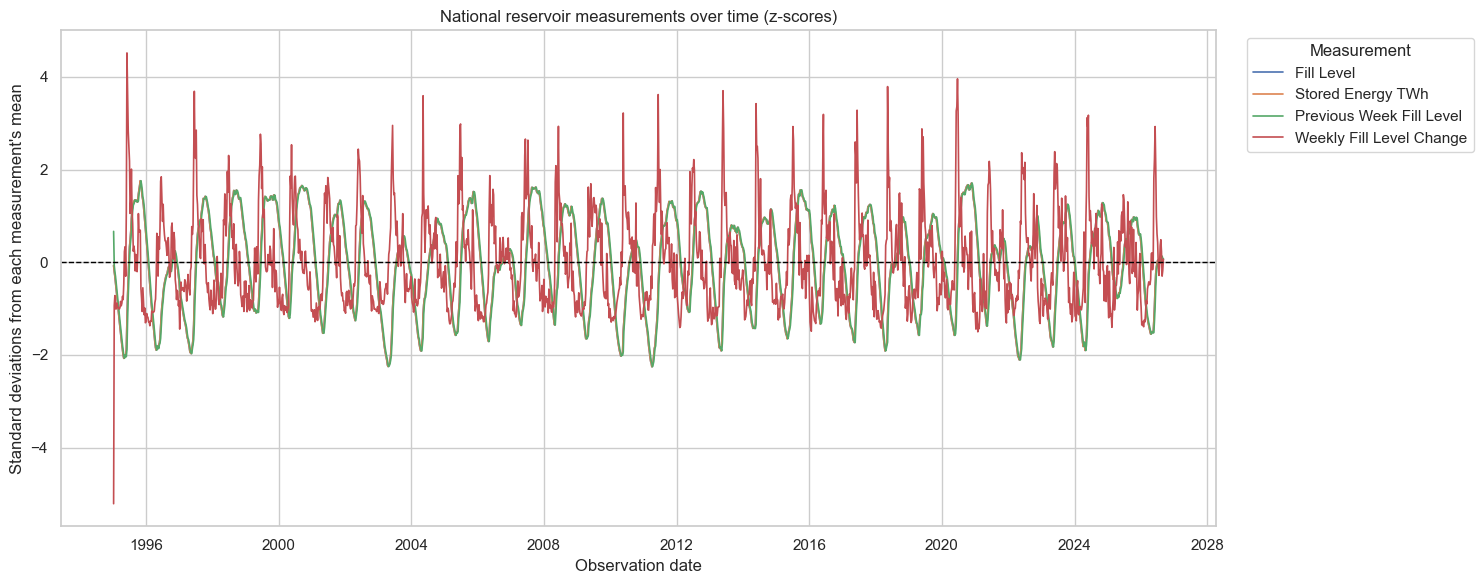

In [4]:
# Compare only the national area's measurements on their actual dates.
national = df.loc[(df["Area Type"] == "NO") & (df["Area Code"] == 0)].copy()
national = national.sort_values("Observation Date")
measurement_columns = [
    "Fill Level",
    "Stored Energy TWh",
    "Previous Week Fill Level",
    "Weekly Fill Level Change",
]

# Standardise each series separately, then reshape for a shared Seaborn line plot.
standardised = (national[measurement_columns] - national[measurement_columns].mean()) / national[measurement_columns].std()
standardised["Observation Date"] = national["Observation Date"].to_numpy()
comparison_data = standardised.melt(
    id_vars="Observation Date", var_name="Measurement", value_name="Z-score"
)

fig, ax = plt.subplots(figsize=(15, 6))
sns.lineplot(
    data=comparison_data, x="Observation Date", y="Z-score", hue="Measurement",
    estimator=None, errorbar=None, linewidth=1.2, ax=ax,
)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("National reservoir measurements over time (z-scores)")
ax.set_xlabel("Observation date")
ax.set_ylabel("Standard deviations from each measurement's mean")
ax.legend(title="Measurement", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

## Compulsory work log

I used this notebook as the main development and documentation workspace for the Norwegian reservoir dataset. It reads the local `reservoirs.csv` file, replaces abbreviated Norwegian headers with readable English names, and parses the observation and next-publication dates. Checking the source columns exposed an early mapping error: Stored Energy TWh had been omitted, which shifted the later names. I corrected the mapping against the CSV before continuing with the analysis.

Because the reservoir data is recorded weekly, I replaced the distribution and box plots with time-series charts. The first Seaborn line plot follows fill level, as a percentage of capacity, across all nine area series. It shows when the levels rise and fall rather than only how often values occur. The second plot focuses on the national series, NO 0, and compares fill level, stored energy, previous-week fill level, and weekly fill-level change on the same dates. I standardised each measurement to its own z-scores before plotting them together, so differences in units and scale do not dominate the comparison. ISO year and week are date information, not measurements, while national capacity is constant and cannot be usefully standardised. The notebook keeps the code, outputs, and explanations together so the analysis can be rerun locally.

I built a four-page Streamlit counterpart from the same CSV. Its home page summarizes the data; the data page shows a first-month line chart for each of nine weekly area series alongside the source records; the plot page lets a viewer choose one series or all nine and select a month range; and the about page explains the area codes. Unlike the notebook's broad exploration, the dashboard plots only numeric fill-level values. The app reshapes those values from long-form source rows into one column per area series, converts them to percentages, and caches the processed data so page reruns do not repeat the CSV work. The interactive plot uses Seaborn, matching the notebook's plotting library, with Matplotlib handling its figure and date-axis formatting.

Working across both environments clarified why the notebook is useful for inspecting and explaining every source field, while Streamlit is better for a focused interactive view. I ran the notebook code cells and checked the four app pages locally, including the area and month controls. The notebook and app code are in the [public GitHub repository](https://github.com/dared22/ind320), and the dashboard is available as a [deployed Streamlit app](https://cklqlkatpe9mqyrnuch2ma.streamlit.app/About).

## AI-tool use

I used AI to help improve the column names and notebook presentation, identify and correct the shifted column mapping, draft and test the plotting code, and implement and check the Streamlit pages and cached data loader. It also helped update the Python dependencies and this documentation. I checked suggestions against the CSV, executed the notebook cells, and tested the app locally. I remain responsible for the analysis, wording, and final submission.